<a href="https://colab.research.google.com/github/Neu-Utkarsh/Practice-PyTorch/blob/main/MyTorch_00/01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Docs
https://www.learnpytorch.io/01_pytorch_workflow/

# PyTorch 00 -> Fundamentals

In [ ]:
import torch

In [ ]:
print(torch.__version__)

2.8.0+cu126


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Tensors
### Creating

In [ ]:
# scalar
scalar = torch.tensor(7)
scalar

tensor(7)

In [ ]:
scalar.ndim
scalar.item()

7

In [ ]:
vector = torch.tensor([7,7])
vector

tensor([7, 7])

In [ ]:
vector.ndim

1

In [ ]:
vector.shape

torch.Size([2])

In [ ]:
Matrix = torch.tensor([[7,8],[9,10]])
Matrix

tensor([[ 7,  8],
        [ 9, 10]])

In [ ]:
Matrix.ndim
Matrix.shape

torch.Size([2, 2])

In [ ]:
Tensor = torch.tensor([[[1,2,3],[3,6,9],[2,4,5]]])
Tensor

tensor([[[1, 2, 3],
         [3, 6, 9],
         [2, 4, 5]]])

In [ ]:
Tensor.ndim
Tensor.shape

torch.Size([1, 3, 3])

In [ ]:
 # Random tensors
 # NN learns using random numbers only
# Start with random nos. -> Look at data -> Update random nos. -> look at data
# -> update random nos

In [ ]:
random_tensor =torch.rand(3,4)
random_tensor

tensor([[0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936],
        [0.8694, 0.5677, 0.7411, 0.4294]])

In [ ]:
random_image_size_tensor = torch.rand(size=(2224,224,3))
random_image_size_tensor.shape, random_image_size_tensor.ndim

(torch.Size([2224, 224, 3]), 3)

In [ ]:
# zeros and ones
ones = torch.ones(size=(3,4))

zeros = torch.zeros(size=(3,4))
zeros,ones.dtype

(tensor([[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]),
 torch.float32)

In [ ]:
# range of tensors
torch.arange(0,10,3)

tensor([0, 3, 6, 9])

In [ ]:
one_to_ten = torch.arange(1,11)

In [ ]:
# tensors-like
ten_zeros = torch.zeros_like(input = one_to_ten)
ten_zeros

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
float_32_tensor = torch.tensor([3,6,9],
                               dtype=torch.int32,
                               device= None,
                               requires_grad= False)
float_32_tensor.dtype

torch.int32

In [ ]:
float_16_tensor = float_32_tensor.type(torch.float16)
float_16_tensor.dtype, float_16_tensor.device

(torch.float16, device(type='cpu'))

### manipulating tensors

In [ ]:
# manipulating tensors
tensor1 = torch.tensor([1,2,3])
tensor1 + 10

tensor([11, 12, 13])

In [ ]:
tensor1-=10

In [ ]:
tensor1*10
torch.add(tensor1,100)

tensor([91, 92, 93])

In [ ]:
#element wise multi
tensor2 = torch.tensor([1,2,3,4])
print(tensor2,"*",tensor2)
print(f"Equals: {tensor2*tensor2}")

tensor([1, 2, 3, 4]) * tensor([1, 2, 3, 4])
Equals: tensor([ 1,  4,  9, 16])


In [ ]:
%%time
print(torch.matmul(tensor2,tensor2))

tensor(30)
CPU times: user 425 µs, sys: 0 ns, total: 425 µs
Wall time: 430 µs


In [ ]:
%%time
value=0
for i in range(len(tensor2)):
  value+=tensor2[i]*tensor2[i]
value

CPU times: user 244 µs, sys: 20 µs, total: 264 µs
Wall time: 268 µs


tensor(30)

In [ ]:
arr= torch.tensor([[[1,2],[2,4]],[[5,6],[6,7]]])
arr.shape

torch.Size([2, 2, 2])

In [ ]:
arr.mT.shape

torch.Size([2, 2, 2])

## Aggregate funcitons

In [ ]:
x = torch.arange(0,100,5).reshape(4,5).type(torch.float32)
x

tensor([[ 0.,  5., 10., 15., 20.],
        [25., 30., 35., 40., 45.],
        [50., 55., 60., 65., 70.],
        [75., 80., 85., 90., 95.]])

In [ ]:
x.mean(axis=1), x.sum(axis=0), x.argmax() # argmx returns position of max no. in a flattened format

(tensor([10., 35., 60., 85.]),
 tensor([150., 170., 190., 210., 230.]),
 tensor(19))

In [ ]:
# stacking, unstacking, squeezing
x_stacked= torch.stack([x,x],dim=0)
x_stacked.shape

torch.Size([2, 4, 5])

In [ ]:
x_stacked.squeeze().shape # no changes bcz it removes the dims which have (1 ,1,3) -> (3)

torch.Size([2, 4, 5])

In [ ]:
# Tensor to numpy
tensor = torch.ones(7)
numpy_tensor = tensor.numpy()
tensor, numpy_tensor

(tensor([1., 1., 1., 1., 1., 1., 1.]),
 array([1., 1., 1., 1., 1., 1., 1.], dtype=float32))

In [ ]:
# Reproducibility
# random seed does is "flavour" the randomness

random_tensor_A = torch.rand(3,4)
random_tensor_B = torch.rand(3,4)

print(random_tensor_A == random_tensor_B)

tensor([[False, False, False, False],
        [False, False, False, False],
        [False, False, False, False]])


In [ ]:
# Using seed
seed = 42
torch.manual_seed(seed)
random_tensor_c = torch.rand(3,4)

torch.manual_seed(seed)
random_tensor_d = torch.rand(3,4)

print(random_tensor_c == random_tensor_d)

tensor([[True, True, True, True],
        [True, True, True, True],
        [True, True, True, True]])


# PyTorch 01 -> Flow

In [ ]:
from torch import nn
import matplotlib.pyplot as plt

## Data preparing and loading

In [ ]:
# to make linear reg model for knwon params
weight = 7
bias = 2
start = 0
end = 1
step =0.02
X = torch.arange(start,end,step).unsqueeze(dim=1)
y= weight * X +bias

X[:10]

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]])

In [ ]:
# Create train/test split
train_split = int(0.8 * len(X)) # 80% of data used for training set, 20% for testing
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [ ]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14})
  plt.show()

In [ ]:
class LinearRegression(nn.Module) :
  def __init__(self) :
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         dtype = torch.float))


  def forward(self,x:torch.Tensor) -> torch.Tensor :
    return self.weights * x + self.bias  # LinearReg formula

In [ ]:
torch.manual_seed(42)
model_0 = LinearRegression()

In [ ]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
X_test

tensor([[0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]])

In [ ]:
with torch.inference_mode() : # no gradients tracking better than no_grad()
  y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

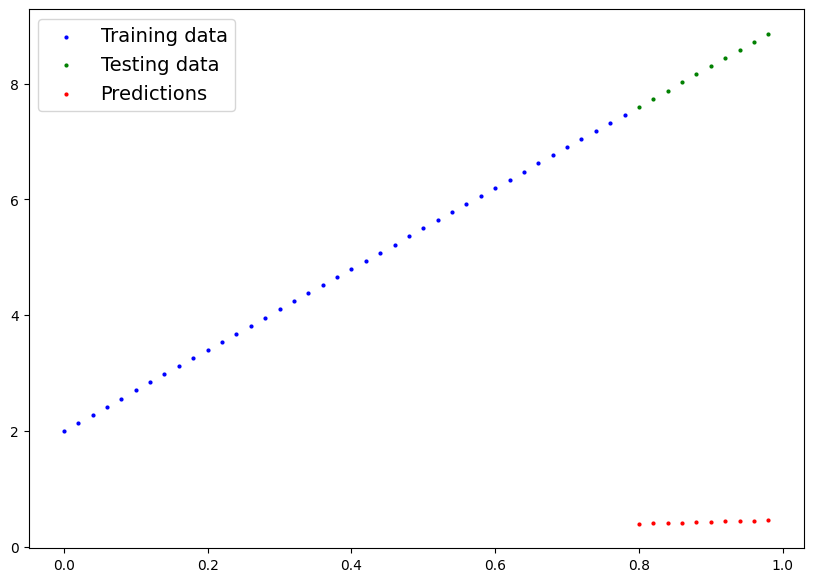

In [ ]:
plot_predictions(predictions=y_preds)

## Training a model

In [ ]:
# Loss Fn..
loss_fn = nn.L1Loss()

# Optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)

In [ ]:
# training loop
epochs=10

#0.
for epoch in range(epochs) :
  model_0.train()
  # 1.
  y_preds = model_0(X_train)
  # 2.
  loss = loss_fn(y_preds,y_train)
  # 3.
  optimizer.zero_grad()
  # 4.
  loss.backward()
  # 5.
  optimizer.step()

  ## Testing Loop
  model_0.eval() # Turns off gradient tracking

  with torch.inference_mode() :
    test_pred = model_0(X_test)
    test_loss = loss_fn(test_pred,y_test)

  print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")

Epoch: 0 | Loss: 4.458360195159912 | Test Loss: 7.774594306945801
Epoch: 1 | Loss: 4.446839332580566 | Test Loss: 7.7611236572265625
Epoch: 2 | Loss: 4.4353179931640625 | Test Loss: 7.747652530670166
Epoch: 3 | Loss: 4.423797130584717 | Test Loss: 7.7341814041137695
Epoch: 4 | Loss: 4.412276268005371 | Test Loss: 7.720709800720215
Epoch: 5 | Loss: 4.400755882263184 | Test Loss: 7.707238674163818
Epoch: 6 | Loss: 4.3892340660095215 | Test Loss: 7.693768501281738
Epoch: 7 | Loss: 4.377713203430176 | Test Loss: 7.6802978515625
Epoch: 8 | Loss: 4.36619234085083 | Test Loss: 7.666825771331787
Epoch: 9 | Loss: 4.354671478271484 | Test Loss: 7.653354644775391


# ALL TOGETHER



In [36]:
import torch
import matplotlib.pyplot as plt
import torch.nn as nn

In [37]:

weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1) # without unsqueeze, errors will happen later on (shapes within linear layers)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [39]:
# Plot
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  plt.figure(figsize=(10, 3))
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  plt.legend(prop={"size": 14})
  plt.show()

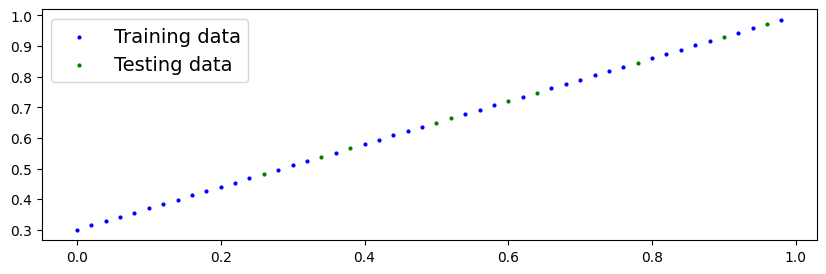

In [40]:
plot_predictions(X_train, y_train, X_test, y_test)

In [41]:
# Subclass nn.Module to make our model
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Use nn.Linear() for creating the model parameters
        self.linear_layer = nn.Linear(in_features=1,
                                      out_features=1)

    # Define the forward computation (input data x flows through nn.Linear())
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

# Set the manual seed when creating the model (this isn't always needed but is used for demonstrative purposes, try commenting it out and seeing what happens)
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [42]:
# Loss function
loss_fn = nn.L1Loss()
# Optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.01)

In [43]:
torch.manual_seed(42)

epochs =200

for epoch in range(epochs):
  model_1.train()

  # Forward pass
  y_pred = model_1(X_train)
  # Calculate loss
  loss = loss_fn(y_pred, y_train)
  # Zero grad optimizer
  optimizer.zero_grad()
  # Loss backward
  loss.backward()
  # Step the optimizer
  optimizer.step()

  ## Testing Loop
  model_1.eval()
  with torch.inference_mode():
    test_pred = model_1(X_test)
    test_loss = loss_fn(test_pred, y_test)

  if epoch %10 ==0 :
    print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")

Epoch: 0 | Loss: 0.5600506067276001 | Test Loss: 0.5552194714546204
Epoch: 10 | Loss: 0.4383816719055176 | Test Loss: 0.42784810066223145
Epoch: 20 | Loss: 0.3167126774787903 | Test Loss: 0.3004767596721649
Epoch: 30 | Loss: 0.19504375755786896 | Test Loss: 0.17310543358325958
Epoch: 40 | Loss: 0.07337480783462524 | Test Loss: 0.04598527029156685
Epoch: 50 | Loss: 0.0360596664249897 | Test Loss: 0.024147968739271164
Epoch: 60 | Loss: 0.029995162039995193 | Test Loss: 0.020626747980713844
Epoch: 70 | Loss: 0.024409985169768333 | Test Loss: 0.01669568382203579
Epoch: 80 | Loss: 0.018832748755812645 | Test Loss: 0.012815380468964577
Epoch: 90 | Loss: 0.013247576542198658 | Test Loss: 0.008884328417479992
Epoch: 100 | Loss: 0.007668554782867432 | Test Loss: 0.005004018545150757
Epoch: 110 | Loss: 0.0020851530134677887 | Test Loss: 0.0010729581117630005
Epoch: 120 | Loss: 0.010759826749563217 | Test Loss: 0.0016480416525155306
Epoch: 130 | Loss: 0.010759826749563217 | Test Loss: 0.001648041

In [44]:
# Turn model into evaluation mode
model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds

tensor([[0.4922],
        [0.8576],
        [0.7311],
        [0.9419],
        [0.5484],
        [0.9841],
        [0.6749],
        [0.6609],
        [0.7592],
        [0.5765]])

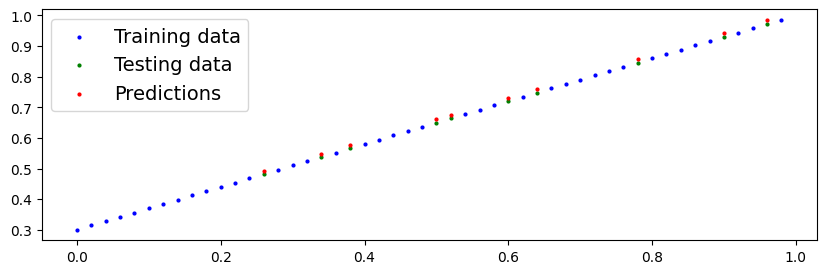

In [45]:
# plot_predictions(predictions=y_preds) # -> won't work... data not on CPU

# Put data on the CPU and plot it
plot_predictions(predictions=y_preds)